In [1]:
%pip install gensim>=4.1.2

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
#from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from collections import Counter
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation, PCA, TruncatedSVD
import random
np.random.seed(42)
random.seed(42)
from gensim.parsing.preprocessing import STOPWORDS
from gensim.utils import simple_preprocess
from gensim.corpora import Dictionary, MmCorpus

In [3]:
data_df = pd.read_csv(r'C:\Users\Shankar\Desktop\Coursework\Introduction to AI and Text Analytics\TextAnalytics-CW-Task4\analytics_pipeline\data\customer_support_tickets.csv')
data_df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [5]:
for column in data_df.columns:
    print(f"{column}: {data_df[column].isnull().sum()} null values")

Ticket ID: 0 null values
Customer Name: 0 null values
Customer Email: 0 null values
Customer Age: 0 null values
Customer Gender: 0 null values
Product Purchased: 0 null values
Date of Purchase: 0 null values
Ticket Type: 0 null values
Ticket Subject: 0 null values
Ticket Description: 0 null values
Ticket Status: 0 null values
Resolution: 5700 null values
Ticket Priority: 0 null values
Ticket Channel: 0 null values
First Response Time: 2819 null values
Time to Resolution: 5700 null values
Customer Satisfaction Rating: 5700 null values


## Univariant Analysis

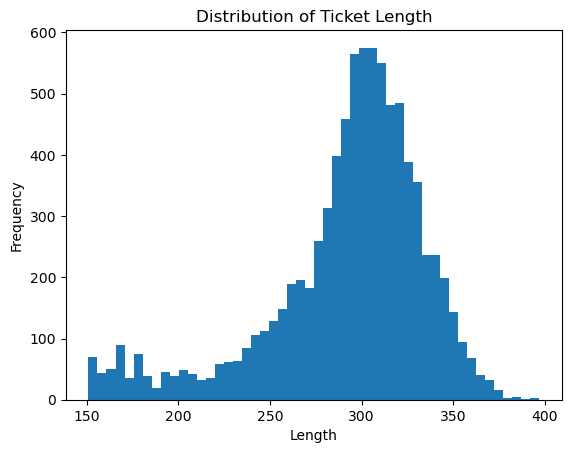

In [6]:
data_df['text_length'] = data_df['Ticket Description'].astype(str).apply(len)

plt.hist(data_df['text_length'], bins=50)
plt.title("Distribution of Ticket Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

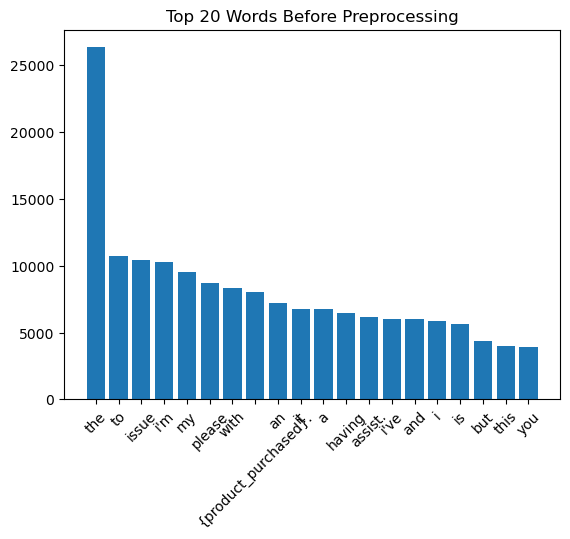

In [7]:
text_data = data_df['Ticket Description'].astype(str)

all_words = " ".join(text_data).lower().split()
common_words = Counter(all_words).most_common(20)

words, counts = zip(*common_words)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words Before Preprocessing")
plt.show()

In [8]:
unique_words = set(all_words)
print("Vocabulary size:", len(unique_words))

Vocabulary size: 13826


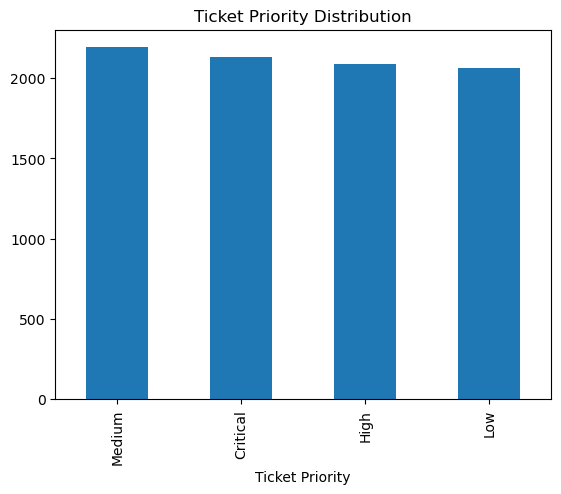

In [9]:
data_df['Ticket Priority'].value_counts().plot(kind='bar')
plt.title("Ticket Priority Distribution")
plt.show()

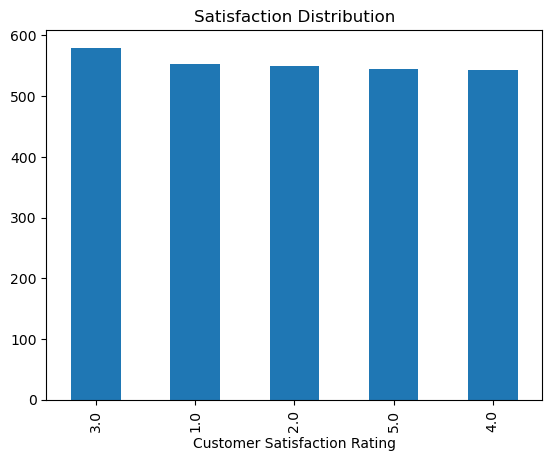

In [10]:
data_df['Customer Satisfaction Rating'].value_counts().plot(kind='bar')
plt.title("Satisfaction Distribution")
plt.show()

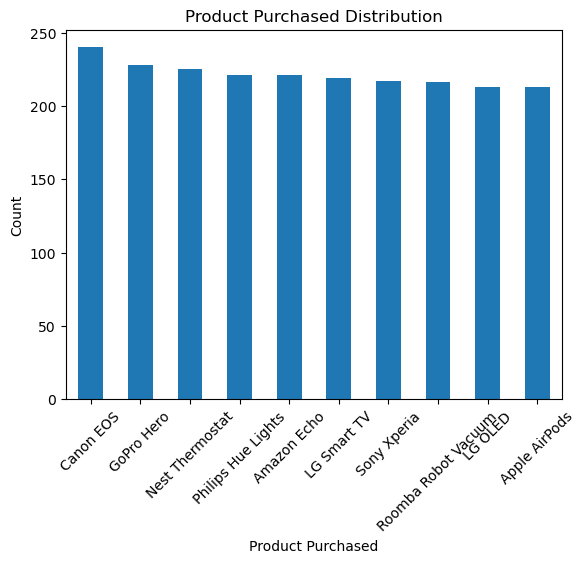

In [11]:
data_df['Product Purchased'].value_counts().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Product Purchased Distribution")
plt.xlabel("Product Purchased")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

Text(0, 0.5, 'Count')

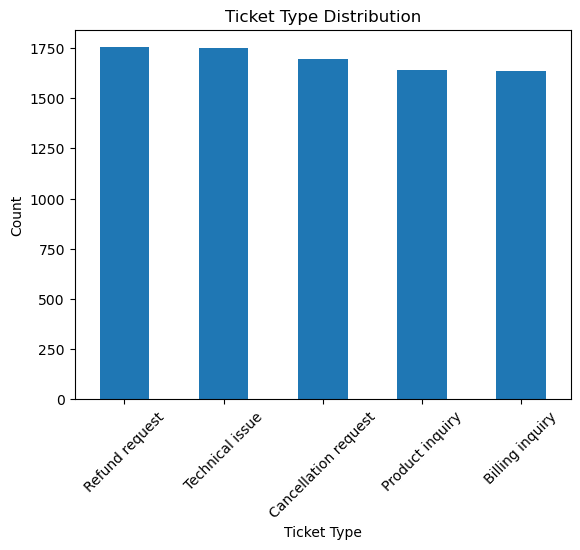

In [12]:
data_df['Ticket Type'].value_counts().plot(kind='bar')
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.xticks(rotation=45)
plt.ylabel("Count")

In [13]:
data_df['Ticket Type'].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [14]:
data_df['Ticket Subject'].unique()

<ArrowStringArray>
[           'Product setup', 'Peripheral compatibility',
          'Network problem',           'Account access',
                'Data loss',            'Payment issue',
           'Refund request',             'Battery life',
     'Installation support',             'Software bug',
           'Hardware issue',   'Product recommendation',
         'Delivery problem',            'Display issue',
     'Cancellation request',    'Product compatibility']
Length: 16, dtype: str

In [15]:
data_df['Ticket Subject'].value_counts()

Ticket Subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64

These are like the ground truth values. Meaning we can use these ticket type to evalute the clusters

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


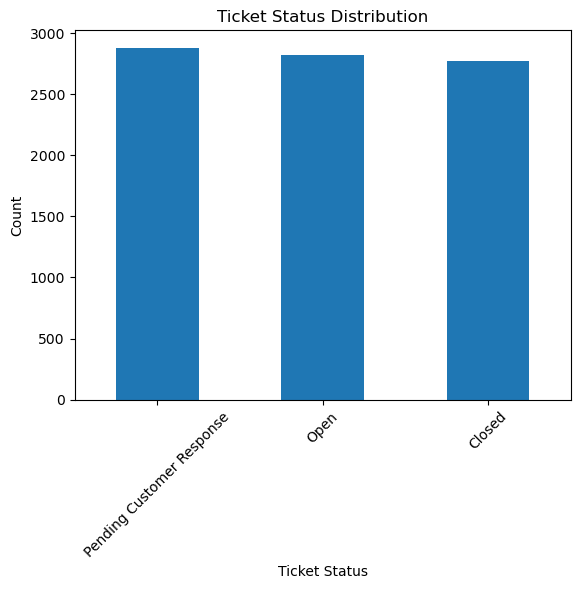

In [16]:
print(data_df['Ticket Type'].value_counts())
data_df['Ticket Status'].value_counts().plot(kind='bar')
plt.title("Ticket Status Distribution") 
plt.xlabel("Ticket Status")
plt.xticks(rotation=45) 
plt.ylabel("Count")
plt.show()  

In [17]:
data_df['Customer Age'].agg(['mean', 'max', 'min'])

mean    44.026804
max     70.000000
min     18.000000
Name: Customer Age, dtype: float64

In [18]:
data_df['Date of Purchase'].agg(['max', 'min'])

max    2021-12-30
min    2020-01-01
Name: Date of Purchase, dtype: str

Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64


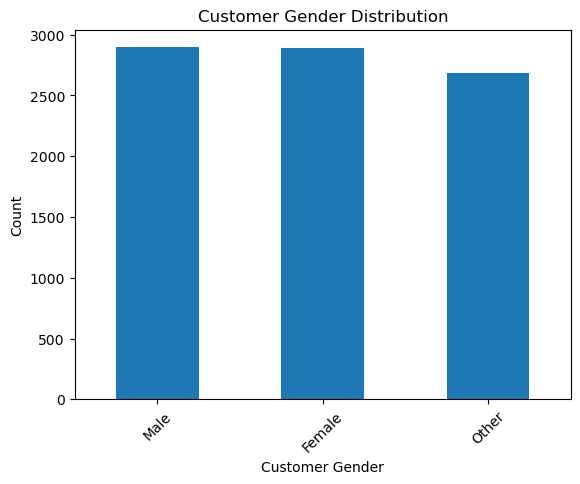

In [19]:
print(data_df['Customer Gender'].value_counts())
data_df['Customer Gender'].value_counts().plot(kind='bar')
plt.title("Customer Gender Distribution")
plt.xlabel("Customer Gender")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

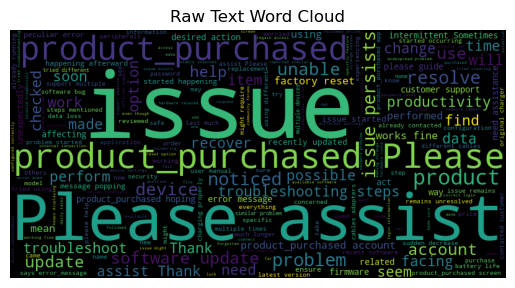

In [20]:
wordcloud = WordCloud(width=800, height=400).generate(" ".join(text_data))

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Raw Text Word Cloud")
plt.show()

Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64


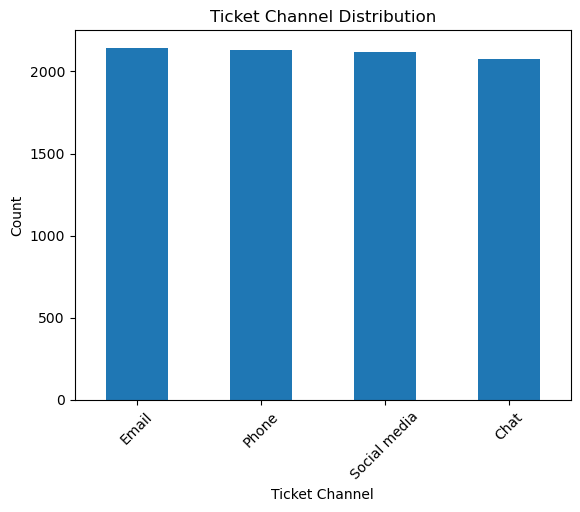

In [21]:
print(data_df['Ticket Channel'].value_counts())
data_df['Ticket Channel'].value_counts().plot(kind='bar')
plt.title("Ticket Channel Distribution")
plt.xlabel("Ticket Channel")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

In [22]:
for i in range(len(data_df['Ticket Description'])):
    text = data_df['Ticket Description'][i]
    exists = bool(re.search(r'\{.*?\}', text))
    if exists:
        found = re.findall(r'\{.*?\}', text)
        if found != "{Product_purchased}":
            print(f"Found patterns in ticket {i}: {found}")

Found patterns in ticket 0: ['{product_purchased}']
Found patterns in ticket 1: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 2: ['{product_purchased}', '{product_purchased}', '{product_purchased}']
Found patterns in ticket 3: ['{product_purchased}']
Found patterns in ticket 4: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 5: ['{product_purchased}', '{product_purchased}', "{product_purch I've checked for any available software updates for my {product_purchased}"]
Found patterns in ticket 6: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 7: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 8: ['{product_purchased}', '{product_purchased}', '{product_purchased}']
Found patterns in ticket 9: ['{product_purchased}']
Found patterns in ticket 10: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 11: ['{product_purchased}']
Found patterns in ticket 12: ['{product_purchased}'

We will have to remove these text messages so that the clusters come out to be clean

## Bivariate Analysis

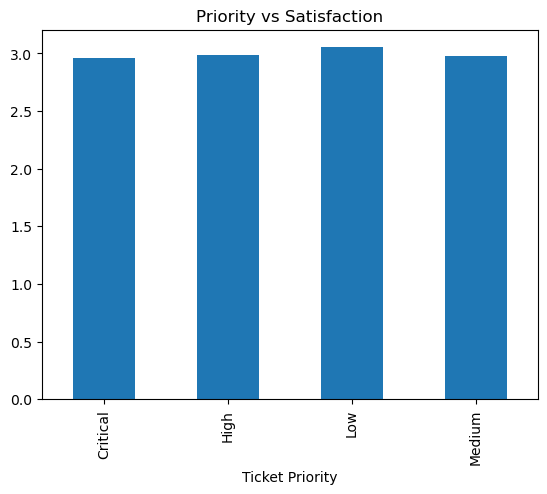

In [23]:
data_df.groupby('Ticket Priority')['Customer Satisfaction Rating'].mean().plot(kind='bar')
plt.title("Priority vs Satisfaction")
plt.show()

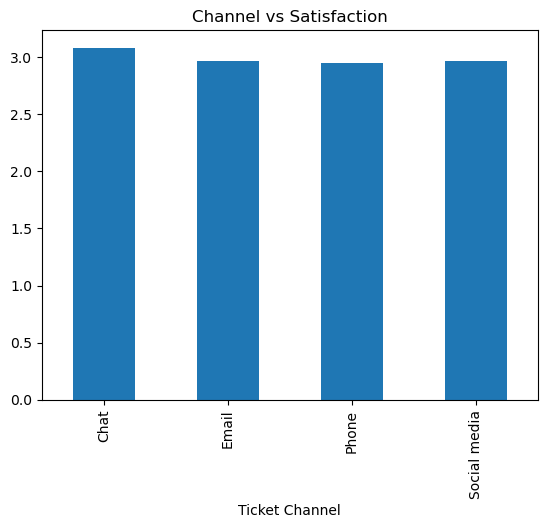

In [24]:
data_df.groupby('Ticket Channel')['Customer Satisfaction Rating'].mean().plot(kind='bar')
plt.title("Channel vs Satisfaction")
plt.show()

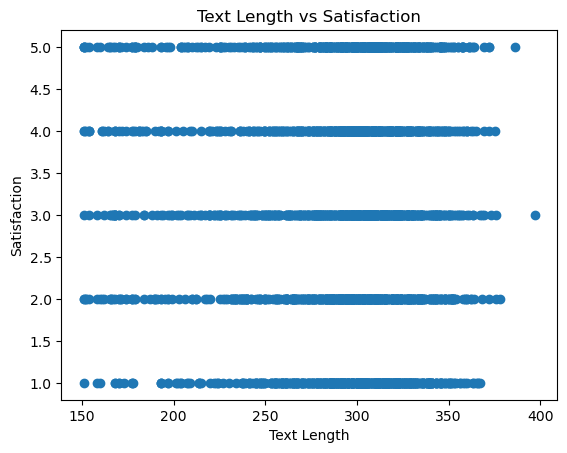

In [25]:
plt.scatter(data_df['text_length'], data_df['Customer Satisfaction Rating'])
plt.xlabel("Text Length")
plt.ylabel("Satisfaction")
plt.title("Text Length vs Satisfaction")
plt.show()

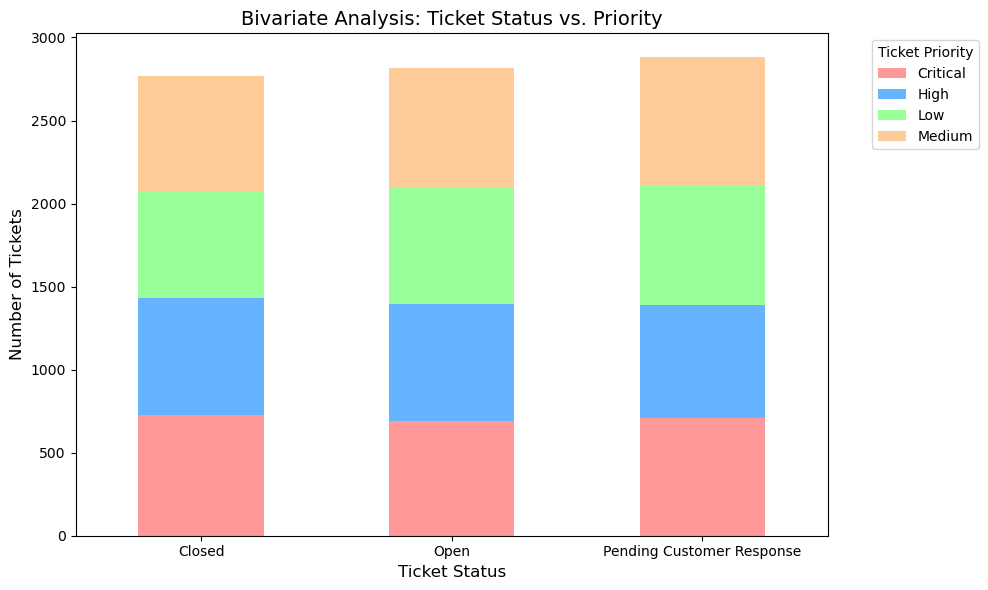

In [26]:
status_priority_map = pd.crosstab(data_df['Ticket Status'], data_df['Ticket Priority'])
status_priority_map.plot(kind='bar', 
                         stacked=True, 
                         figsize=(10, 6), 
                         color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])

plt.title("Bivariate Analysis: Ticket Status vs. Priority", fontsize=14)
plt.xlabel("Ticket Status", fontsize=12)
plt.ylabel("Number of Tickets", fontsize=12)
plt.legend(title="Ticket Priority", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

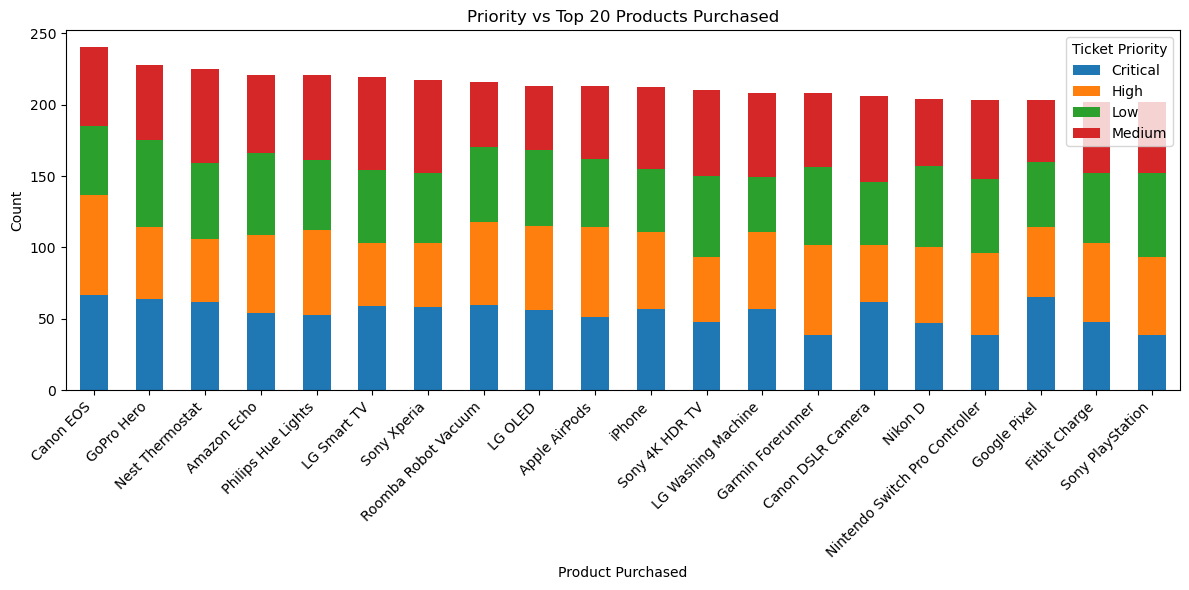

In [27]:
top_20_products = data_df['Product Purchased'].value_counts().nlargest(20).index
filtered_df = data_df[data_df['Product Purchased'].isin(top_20_products)]
plot_data = filtered_df.groupby(['Product Purchased', 'Ticket Priority']).size().unstack()
plot_data['Total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values('Total', ascending=False).drop(columns='Total')

plot_data.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Priority vs Top 20 Products Purchased")
plt.xlabel("Product Purchased")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Ticket Priority')
plt.tight_layout()
plt.show()

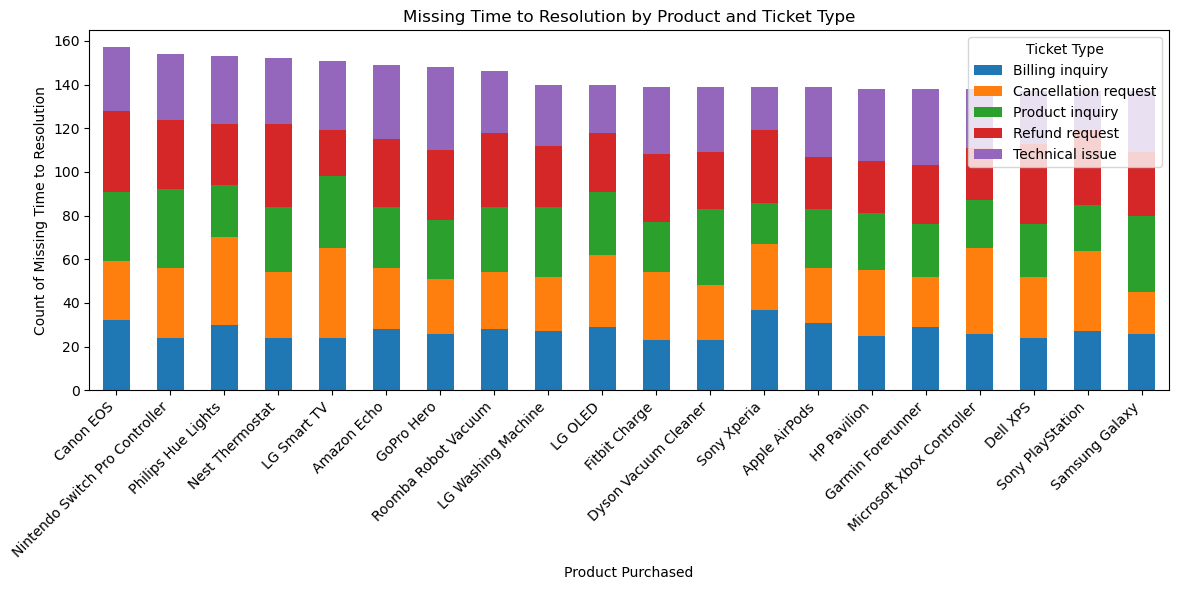

In [28]:
missingdata = data_df['Time to Resolution'].isnull()
missingplotdata_df = data_df[missingdata].groupby(['Product Purchased', 'Ticket Type']).size().unstack()
missingplotdata_df = missingplotdata_df.assign(Total=missingplotdata_df.sum(axis=1)).sort_values(by='Total', ascending=False).drop(columns='Total').head(20)
missingplotdata_df.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Missing Time to Resolution by Product and Ticket Type")
plt.xlabel("Product Purchased")
plt.ylabel("Count of Missing Time to Resolution")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

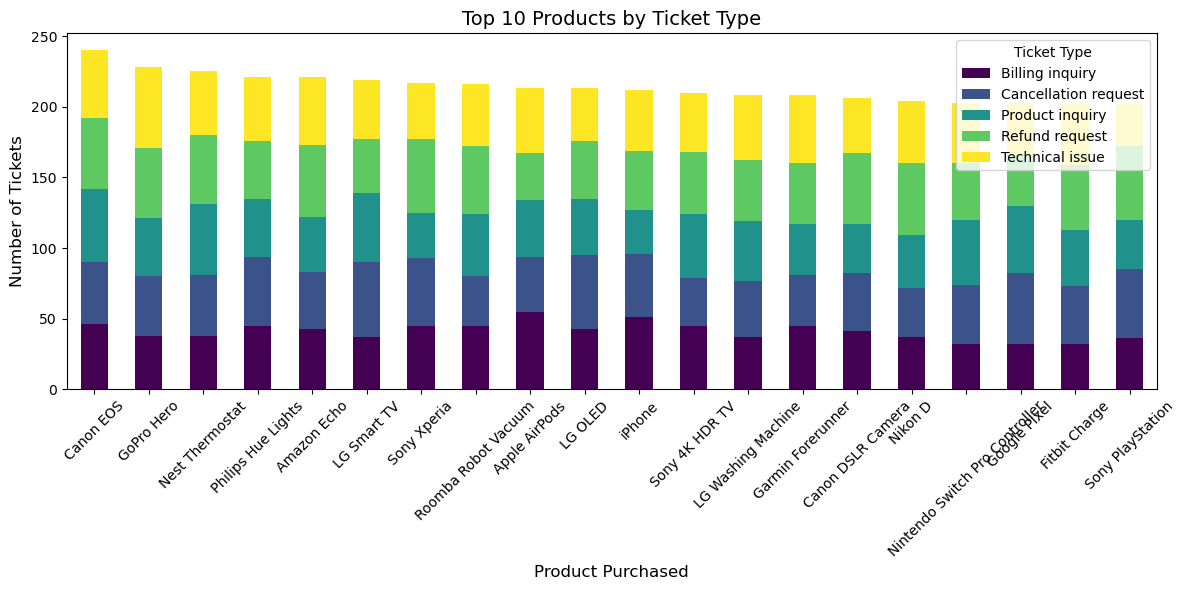

In [29]:
plot_data = data_df.groupby(['Product Purchased', 'Ticket Type']).size().unstack()
plot_data = plot_data.assign(Total=plot_data.sum(axis=1)).sort_values(by='Total', ascending=False).drop(columns='Total').head(20)
plot_data.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title("Top 10 Products by Ticket Type", fontsize=14)
plt.xlabel("Product Purchased", fontsize=12)
plt.ylabel("Number of Tickets", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Ticket Type")
plt.tight_layout()

## Multivariant Analysis

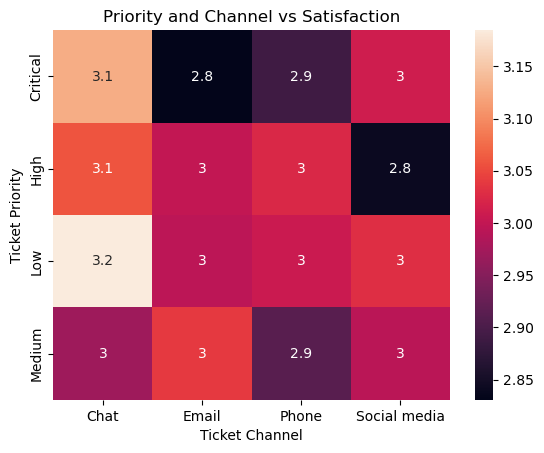

In [30]:
pivot = data_df.pivot_table(values='Customer Satisfaction Rating',index='Ticket Priority',columns='Ticket Channel',aggfunc='mean')
sns.heatmap(pivot, annot=True)
plt.title("Priority and Channel vs Satisfaction")
plt.show()

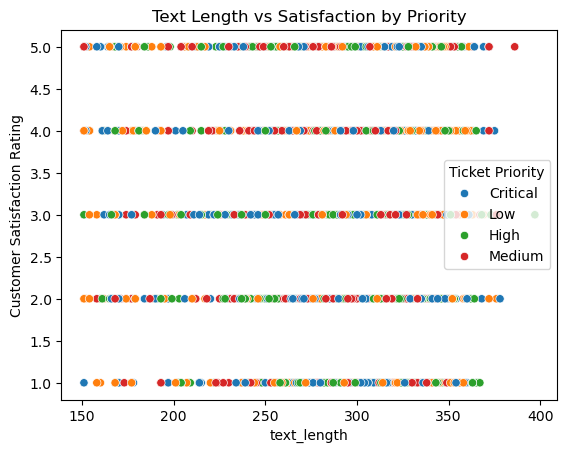

In [31]:
sns.scatterplot(data=data_df,x='text_length',y='Customer Satisfaction Rating',hue='Ticket Priority')
plt.title("Text Length vs Satisfaction by Priority")
plt.show()

## Preprocessing

In [32]:
# for i in range(len(data_df)):
#     product_purchased = data_df.iloc[i]['Product Purchased']
#     text = data_df.iloc[i]['Ticket Description']
#     updated_text = text.replace('{product_purchased}', product_purchased)
#     data_df.at[data_df.index[i], 'Ticket Description'] = updated_text


# data_df.head()

In [33]:
duplicates = data_df['Ticket Description'].duplicated()
duplicates.sum()

np.int64(392)

In [34]:
data_df = data_df.drop_duplicates(subset=['Ticket Description'], keep='first')
data_df.reset_index(drop=True, inplace=True)

In [35]:
#data_df['text'] = data_df['Ticket Subject'].fillna('') + " " + data_df['Ticket Description'].fillna('')
data_df['text'] = data_df['Ticket Description'].fillna('')

In [36]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}|\[.*?\]|<.*?>|\(.*?\)', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text) # remove URLs
    text = re.sub(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', ' ', text) # remove email addresses
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # remove non-ASCII characters
    text = re.sub(r'[^a-z\s]', '', text) 
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)  # remove very short words
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data_df['clean_text'] = data_df['text'].apply(clean_text)
data_df['clean_text'].head()

0    having issue with the please assist your billi...
1    having issue with the please assist you need c...
2    facing problem with the not turning was workin...
3    having issue with the please assist you have p...
4    having issue with the please assist note the s...
Name: clean_text, dtype: str

In [ ]:
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')

# stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# removing the words from the word cloud which i did above
#custom_words = {'please', 'help', 'issue', 'product', 'customer'}


###overfitting
# custom_words = {
#     'please', 'help', 'assist', 'support', 'thanks', 'thank','would',
#     'could', 'im', 'ive', 'issue','problem','hoping','contacted','tried',
#     'trying', 'check', 'checked', 'perform', 'performed','need', 'want',
#     'using', 'use', 'used', 'user', 'us','time','happening','everything',
#     'something', 'anything','customer', 'product', 'purchased', 'request',
#     'refund', 'payment', 'delivery', 'item','also', 'already', 'multiple',
#     'recently','didnt', 'did','get', 'getting', 'make', 'made','data','step',
#     'noticed','work','fine','available','facing','might','option','say', 'find',
#     'doe', 'like', 'seems', 'guide', 'message','sure', 'soon', 'mean', 'different',
#     'productivity', 'specific', 'troubleshooting', 'troubleshoot',
#     'possible', 'action', 'setting', 'setup', 'installation',
#     'recommendation', 'assistance','way','sometimes','act','related','havent',
#     'information', 'try','desired','new','recent','afterward','affecting','cancellation','contact', 'remains', 'occuring',
#     'account', 'device', 'hardware', 'network',
#     'software', 'compatibility', 'working', 'properly', 'configuration',
#     'none', 'update', 'updated', 'started',
#     'order', 'purchase', 'name', 'email',
#     'access', 'display', 'know', 'loss',
#     'fix', 'price', 'one', 'add', 'note', 'may', 'dont', 'store'

# }

####too harsh
# custom_words = {
#     'please', 'help', 'assist', 'support', 'thanks', 'thank','would',
#     'could', 'im', 'ive', 'issue','problem','hoping','contacted','tried',
#     'trying', 'check', 'checked', 'perform', 'performed','need', 'want',
#     'using', 'use', 'used', 'user', 'us','time','happening','everything',
#     'something', 'anything','customer', 'product', 'purchased', 'request',
#     'refund', 'payment', 'delivery', 'item','also', 'already', 'multiple',
#     'recently','didnt', 'did','get', 'getting', 'make', 'made','data','step',
#     'noticed','work','fine','available','facing','might','find','does',
#     'seems', 'guide','sure','soon','different','productivity','specific',
#     'possible','setup','installation','recommendation','assistance','way',
#     'sometimes','act','related','havent','information','try','desired','new',
#     'recent','afterward','affecting','cancellation','contact','remains','occuring',
#     'working','properly','none','order','purchase','name','email',
#     'know','price','one','add','note','may','dont','store'
# }

####not very proper clusters
# custom_words = {
#     'please', 'help', 'assist', 'support', 'thanks', 'thank','soon','mentioned',
#     'im', 'ive', 'us','would', 'could', 'need', 'want', 'trying',
#     'tried','check', 'checked', 'make', 'made', 'get', 'getting','also',
#     'use', 'using', 'used','thing', 'something', 'anything', 'everything',
#     'way', 'time','issue', 'problem', 'request',
#     'work', 'working', 'fine', 'available', 'recent', 'recently','facing', 'doe',
#     'noticed', 'happening', 'started', 'happen','different', 'steps', 'did',
#     'regards','already', 'multiple','last','times','followed', 'reviewed',
#     'specific', 'possible', 'related','new', 'old','find', 'try', 'trying', 'say', 'mean',
#     'name', 'email', 'price', 'one', 'add','note', 'may', 'dont', 'know','sure',
#     'changes', 'performed', 'properly','original','like', 'similar','reported','doesnt',
#     'sometimes', 'acts', 'works', 'ensure', 'desired', 'action', 'remains', 'life', 'seems',
#     'might', 'guide', 'much', 'others',
#     'heavily', 'daily', 'task',
#     'affecting', 'assistance',
#     'hoping','persists','didnt',
#     'option', 'perform', 'recommendation', 'information', 'official',
#     'solution', 'provide', 'making',
#     'user', 'customer',
#     'item', 'device',
#     'far', 'luck','contact', 'contacted', 'occurring', 'having'
# }
custom_words = {'please', 'assist', 'issue', 'persists', 'product', 'using', 'help', 'resolve', 'function', 'var', 'let', 
                    'having', 'problem', 'thank', 'need', 'soon', 'possible', 'hoping', 'assistance', 'desired', 'customer', 'support', 
                    'step', 'guide', 'action', 'option', 'different', 'available', 'tried', 'facing', 'noticed', 'unable', 'started', 'happening',
                      'afterward', 'related', 'checked', 'perform', 'performed', 'occurring', 'affecting', 'haven', 'change', 'work', 'fine', 'time', 
                      'recent', 'recently',  'specific', 'thanks', 'like', 'sure', 'say', 'mean', 'user', 'came', 'remains', 'mentioned', 'item', 'order', 
                      'ensure', 'followed', 'reviewed', 'working', 'properly', 'contacted', 'contact', 'unresolved', 'able'}
# {
#     'solution', 'provide', 'making',
#     'user', 'customer',
#     'item', 'device',
#     'far', 'luck','contact', 'contacted', 'occurring'
# }
# {
#     'customer', 'product', 'purchased', 'order', 'purchase',
#     'refund', 'payment', 'delivery', 'item'
# }
# 'customer', 'product',
# 'refund', 'payment', 'delivery',
# 'order', 'purchase', 'item'
# 'refund', 'payment', 'delivery', 'order', 'purchase', 'product'
# 'issue', 'problem', 'request'
#    'hoping', 'contacted','perform', 'performed','step','unresolved', 'persists',
#   'information'

#'hardware', 'software', 'account'
# remmvoing the workds 'software', 'device', 'issue' as they are very common and not useful for clustering

final_stopwords = STOPWORDS.union(custom_words)
custom_words_lemma = set([lemmatizer.lemmatize(w.lower()) for w in final_stopwords])

def preprocess(text):
    text = str(text).lower()
    tokens = simple_preprocess(text, deacc=True)

    
    processed_tokens = []
    
    for word in tokens:
        lemma = lemmatizer.lemmatize(word)

        if (lemma not in custom_words_lemma and 
            len(lemma) > 2 and 
            lemma.isalnum()):
            processed_tokens.append(lemma)
    
    return " ".join(processed_tokens)

# Apply to your dataframe
data_df['processed_text'] = data_df['clean_text'].apply(preprocess)

In [38]:
print(len(data_df['processed_text']))

8077


In [39]:
data_df[['text', 'processed_text']].head(5)

,text,processed_text
0,I'm having an issue with the {product_purchase...,billing zip code appreciate requested website ...
1,I'm having an issue with the {product_purchase...,existing intermittent act unexpectedly
2,I'm facing a problem with my {product_purchase...,turning yesterday doesnt respond original char...
3,I'm having an issue with the {product_purchase...,youre interested love happen check feedback iv...
4,I'm having an issue with the {product_purchase...,note seller responsible damage arising deliver...


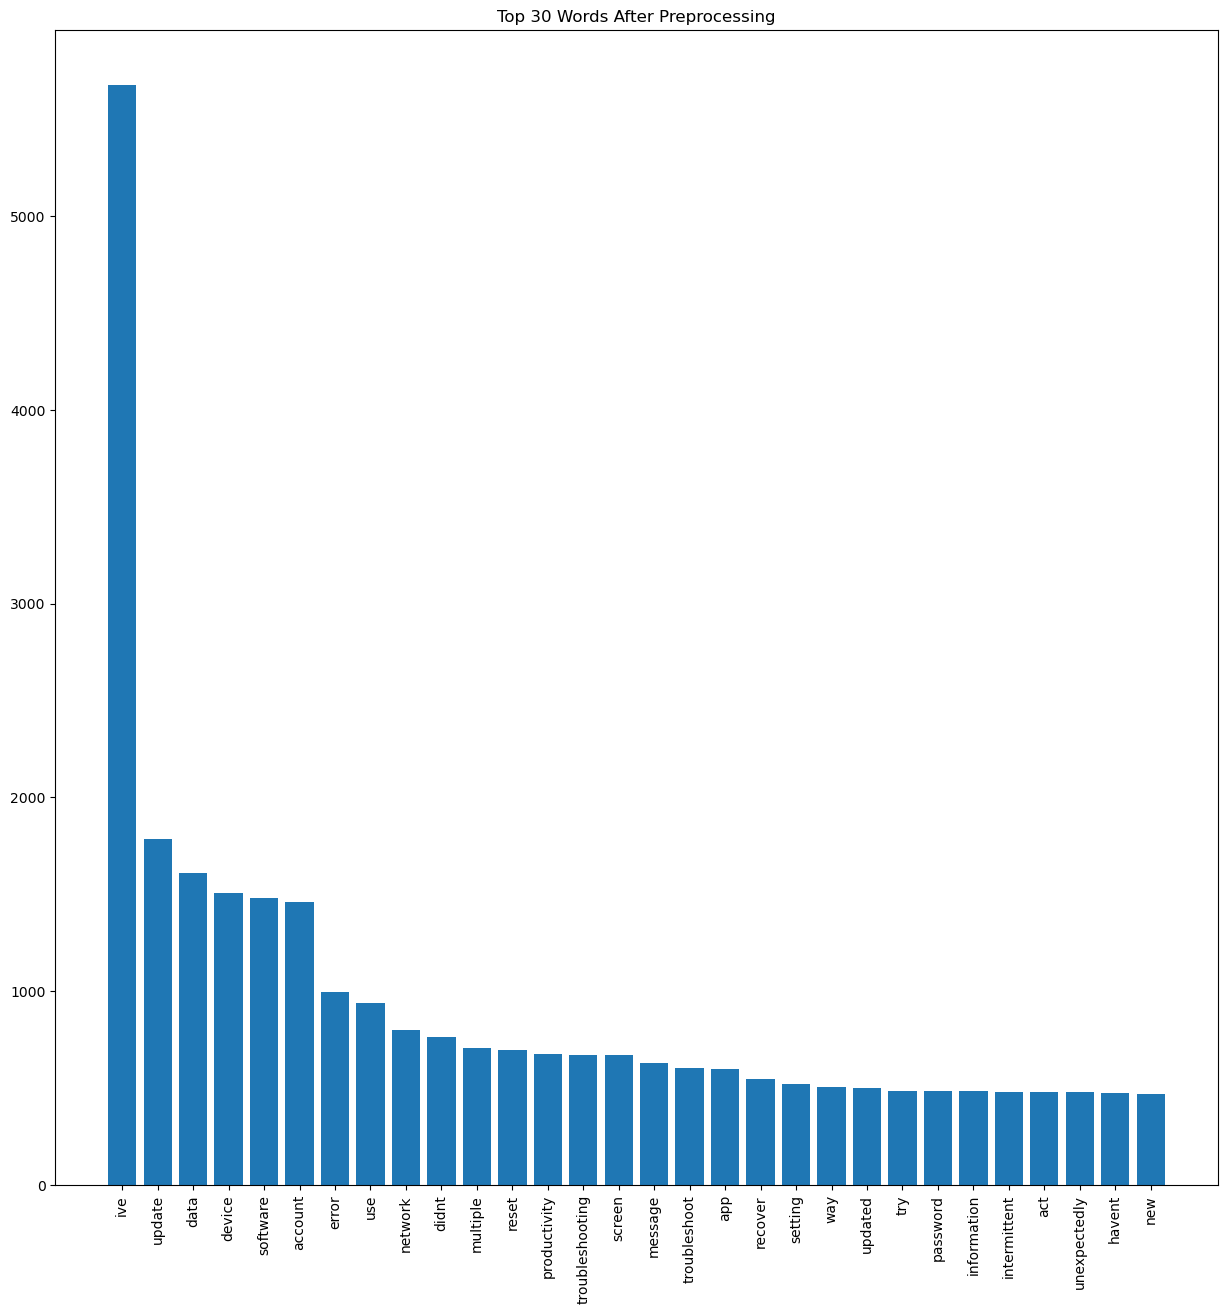

In [40]:
text_data = data_df['processed_text'].astype(str)

all_words = " ".join(text_data).lower().split()
common_words = Counter(all_words).most_common(30)

words, counts = zip(*common_words)

plt.figure(figsize=(15, 15))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 30 Words After Preprocessing")
plt.show()

### TFIDF

In [41]:
tfidf = TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7)

X = tfidf.fit_transform(data_df['processed_text'])

In [42]:
X.shape

(8077, 1000)

In [43]:
X = normalize(X)

In [44]:
x_df = pd.DataFrame(X.toarray())
print(x_df.head())

   0    1    2    3    4    5    6    7    8    9    ...  990  991      992  \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.00000   
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.00000   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.30208   
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.00000   
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.00000   

        993  994  995       996  997  998  999  
0  0.000000  0.0  0.0  0.000000  0.0  0.0  0.0  
1  0.000000  0.0  0.0  0.000000  0.0  0.0  0.0  
2  0.303123  0.0  0.0  0.000000  0.0  0.0  0.0  
3  0.000000  0.0  0.0  0.273604  0.0  0.0  0.0  
4  0.000000  0.0  0.0  0.000000  0.0  0.0  0.0  

[5 rows x 1000 columns]


### Embeddings

In [45]:
# def clean_for_embeddings(text):
#     text = text.lower()
#     text = re.sub(r'\{.*?\}', ' ', text)
#     text = re.sub(r'http\S+', ' ', text)
#     text = re.sub(r"i'?m having an issue with.*?please assist\.?", ' ', text)
#     text = re.sub(r'please assist\.?', ' ', text)
#     text = re.sub(r'\b(id|created_at|product|price)\b', ' ', text)
#     text = re.sub(r'[^a-z\s]', ' ', text)
#     text = re.sub(r'\s+', ' ', text).strip()
#     return text

In [46]:
data_df['embedding_text'] = data_df['text'].apply(clean_text)

In [47]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [48]:
embeddings = model.encode(data_df['embedding_text'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/253 [00:00<?, ?it/s]

In [49]:
embeddings = normalize(embeddings)

In [50]:
embeddings.shape

(8077, 384)

In [51]:
embedding_df = pd.DataFrame(embeddings)
print(embedding_df.head())

        0         1         2         3         4         5         6    \
0 -0.014754 -0.013679  0.042345 -0.001275 -0.010344 -0.034930 -0.066367   
1 -0.035579 -0.061884  0.074353 -0.061262  0.009314  0.009852  0.003103   
2 -0.042789  0.040711  0.032467  0.026602  0.018641 -0.068581 -0.077239   
3 -0.029407 -0.014946  0.005452 -0.027527  0.008063  0.018934 -0.043829   
4 -0.004375  0.094012  0.038334 -0.059777  0.017355  0.041968  0.004439   

        7         8         9    ...       374       375       376       377  \
0 -0.067233 -0.007920  0.037452  ... -0.006493 -0.006382 -0.038616 -0.056016   
1 -0.026080  0.009591 -0.046511  ...  0.050198 -0.007812  0.037102 -0.112791   
2 -0.026262  0.034878 -0.017625  ...  0.039694  0.006324 -0.037685  0.029030   
3 -0.057573  0.040983 -0.012528  ... -0.004655 -0.061442  0.037967 -0.039150   
4  0.036441  0.003622  0.116811  ...  0.009079  0.052836  0.032956  0.010992   

        378       379       380       381       382       383  
0 -0

In [52]:
cosine_similarity([embeddings[0]], [embeddings[1]])

array([[0.4567099]], dtype=float32)

In [53]:
cosine_similarity([embeddings[2]], [embeddings[5]])

array([[0.6477549]], dtype=float32)

## Model

### Kmeans

#### TFIDF

c:\Users\Shankar\.conda\envs\text_analytics\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Shankar\.conda\envs\text_analytics\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Shankar\.conda\envs\text_analytics\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Shankar\.conda\envs\text_analytics\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, *

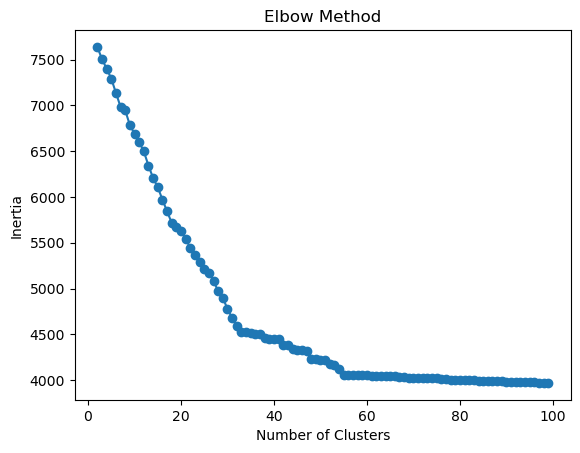

In [54]:
inertia = []

for k in range(2, 100):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(range(2,100), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

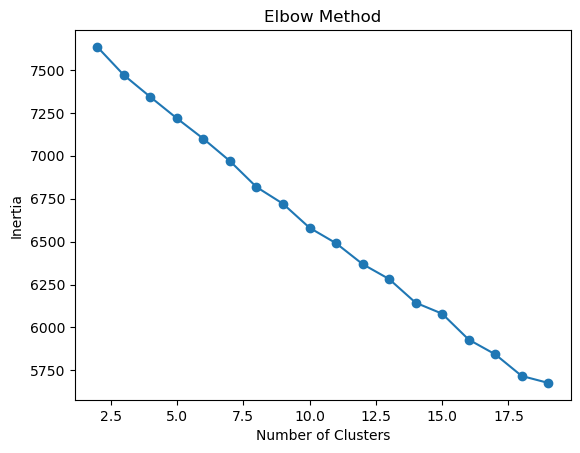

In [55]:
inertia = []
sil_scores = []
score = []

for k in range(2, 20):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    scoree = silhouette_score(X, model.labels_)
    score.append(scoree)
    inertia.append(model.inertia_)
    sil_scores.append(scoree)

plt.plot(range(2,20), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()


k=2, Silhouette Score=0.0202
k=3, Silhouette Score=0.0304
k=4, Silhouette Score=0.0376
k=5, Silhouette Score=0.0462
k=6, Silhouette Score=0.0530
k=7, Silhouette Score=0.0608
k=8, Silhouette Score=0.0715
k=9, Silhouette Score=0.0766
k=10, Silhouette Score=0.0871
k=11, Silhouette Score=0.0936
k=12, Silhouette Score=0.1018
k=13, Silhouette Score=0.1059
k=14, Silhouette Score=0.1141
k=15, Silhouette Score=0.1195
k=16, Silhouette Score=0.1294
k=17, Silhouette Score=0.1332
k=18, Silhouette Score=0.1435
k=19, Silhouette Score=0.1452


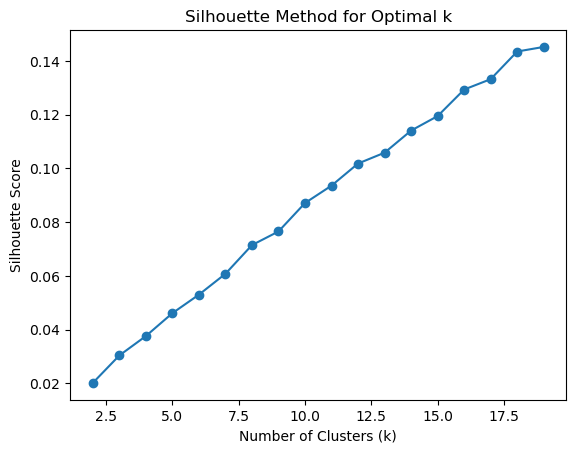

In [56]:
for k in range(2, 20):
    print(f"k={k}, Silhouette Score={score[k-2]:.4f}")
plt.plot(range(2,20), sil_scores,  marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.show()

In [57]:
k = 14

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
data_df['cluster'] = kmeans.fit_predict(X)

In [58]:
terms = tfidf.get_feature_names_out()

def get_top_words_per_cluster(model, X, n=20):
    centroids = model.cluster_centers_
    
    for i in range(len(centroids)):
        top_indices = centroids[i].argsort()[-n:]
        top_words = [terms[j] for j in top_indices]
        
        print(f"\nCluster {i}:")
        print(top_words)

get_top_words_per_cluster(kmeans, X)


Cluster 0:
['purchased', 'purchase', 'use', 'try', 'network', 'ive', 'update running', 'running', 'latest', 'latest version', 'running latest', 'version', 'device', 'ive software', 'havent', 'update havent', 'havent device', 'update', 'software', 'software update']

Cluster 1:
['information regain', 'invalid credential', 'account displaying', 'regain access', 'credential', 'reset recover', 'regain', 'ive forgotten', 'login information', 'forgotten', 'forgotten password', 'password account', 'recover account', 'password reset', 'account password', 'login', 'access', 'access account', 'password', 'account']

Cluster 2:
['fix', 'purchased', 'app', 'know', 'doesnt', 'purchase', 'dont', 'try', 'network', 'email', 'new', 'account', 'use', 'data', 'security', 'concerned', 'security data', 'concerned security', 'safe', 'data safe']

Cluster 3:
['urgently', 'recover deleted', 'file urgently', 'deleted file', 'important', 'ive accidentally', 'deleted important', 'accidentally', 'important data'

| Cluster | Name                                           | Quality|
| ------- | ---------------------------------------------- | -------|
| 0       | Device, Hardware & Troubleshooting Issues      | Good   |
| 1       | Data Loss & Security Concerns                  | Good   |
| 2       | Network & WiFi Connectivity Issues             | Good   |
| 3       | System Errors & Firmware/Update Issues         | Good   |
| 4       | Software Bugs & UI Errors                      | Good   |
| 5       | Account Access & Password Recovery Issues      | Good   |
| 6       | User Troubleshooting & External Help Behaviour | Bad    |





### Embeddings

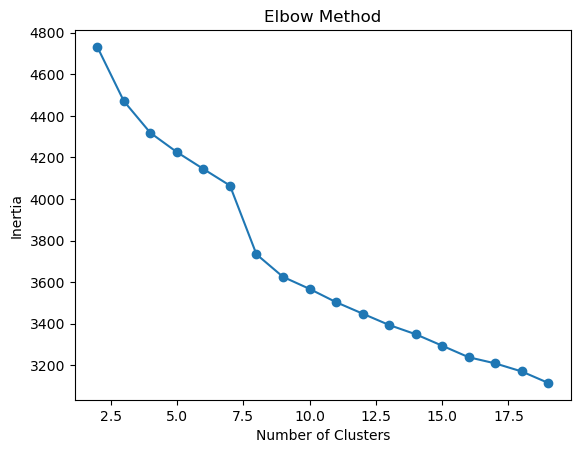

In [59]:
inertiae = []
sil_scorese = []
scoree = []

for k in range(2, 20):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(embeddings)
    inertiae.append(model.inertia_)
    sil_scorese.append(silhouette_score(embeddings, model.labels_))
    scoree.append(silhouette_score(embeddings, model.labels_))
    
plt.plot(range(2,20), inertiae, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

k=2, Silhouette Score=0.1043
k=3, Silhouette Score=0.1108
k=4, Silhouette Score=0.1239
k=5, Silhouette Score=0.0646
k=6, Silhouette Score=0.0622
k=7, Silhouette Score=0.0718
k=8, Silhouette Score=0.1099
k=9, Silhouette Score=0.1123
k=10, Silhouette Score=0.1143
k=11, Silhouette Score=0.1169
k=12, Silhouette Score=0.1176
k=13, Silhouette Score=0.1179
k=14, Silhouette Score=0.1233
k=15, Silhouette Score=0.1216
k=16, Silhouette Score=0.1277
k=17, Silhouette Score=0.1238
k=18, Silhouette Score=0.1252
k=19, Silhouette Score=0.1266


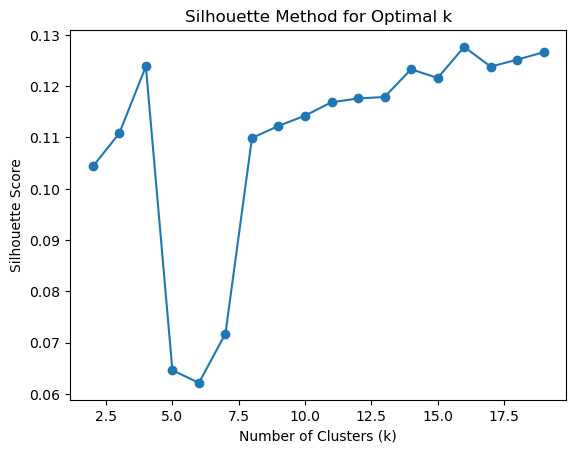

In [60]:
for k in range(2, 20):
    print(f"k={k}, Silhouette Score={scoree[k-2]:.4f}")
plt.plot(range(2,20), sil_scorese,  marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.show()

In [61]:
k = 14

kmeans_embed = KMeans(n_clusters=k, random_state=42, n_init=20)
data_df['cluster_embed'] = kmeans_embed.fit_predict(embeddings)

In [62]:
for i in range(k):
    print(f"\nCluster {i}:")
    print(data_df[data_df['cluster_embed'] == i]['embedding_text'].head(5).tolist())


Cluster 0:
['having issue with the please assist wanted picture for but already bought lot items found online cart fountain dreams collection unable find the option perform the desired action the could you please guide through the steps', 'having issue with the please assist have not yet provided address name for this product this website does not exist please contact with this information and will provide need assistance soon possible because its affecting work and productivity', 'having issue with the please assist please dont dont see issue please contact unable find the option perform the desired action the could you please guide through the steps', 'having issue with the please assist please please need assistance soon possible because its affecting work and productivity', 'having issue with the please assist the requested address will returned within business days please not hesitate contact using the appropriate form weeks from purchase time unable find the option perform the d

| Cluster | Name                                       | Quality   |
| ------- | ------------------------------------------ | --------- |
| 0       | Data Loss, Security & Battery Issues       | Ok  |
| 1       | Network Connectivity & Setup Issues        | Good      |
| 2       | Software Bugs & Firmware Update Issues     | Good      |
| 3       | Payment, Hardware & Intermittent Issues    | Ok  |
| 4       | Hardware Compatibility & Unresolved Issues | Good      |
| 5       | Battery Performance & Software Glitches    | Good      |
| 6       | Account Access & Authentication Issues     | Good |


### HAC

In [63]:
X_dense = X.toarray()

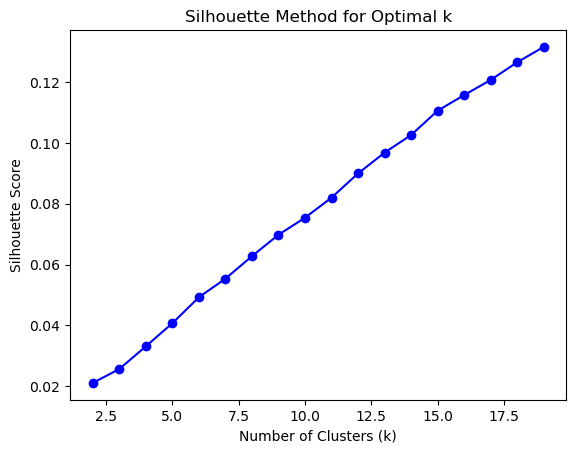

In [64]:
scores = []
k_range = range(2, 20) # Silhouette requires at least 2 clusters

for k in k_range:
    hac = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hac.fit_predict(X_dense)
    score = silhouette_score(X_dense, labels)
    scores.append(score)

plt.plot(k_range, scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.show()

In [65]:
hac_tfidf = AgglomerativeClustering(
    n_clusters=14,
    linkage='ward'
)

data_df['cluster_hac_tfidf'] = hac_tfidf.fit_predict(X_dense)

In [66]:
for i in range(14):
    print(f"\nCluster {i}:")
    
    indices = np.where(data_df['cluster_hac_tfidf'] == i)[0]
    cluster_tfidf = X[indices].mean(axis=0)
    
    top_indices = np.argsort(cluster_tfidf.A1)[-20:][::-1]
    terms = tfidf.get_feature_names_out()
    
    print([terms[j] for j in top_indices])


Cluster 0:
['making', 'making strange', 'strange', 'noise', 'strange noise', 'noise functioning', 'functioning', 'functioning suspect', 'suspect hardware', 'suspect', 'hardware', 'glitch', 'freeze', 'provide solution', 'frequently making', 'freeze frequently', 'difficult use', 'making difficult', 'use provide', 'software freeze']

Cluster 1:
['account', 'reset', 'password', 'factory reset', 'factory', 'reset didnt', 'ive factory', 'didnt', 'ive', 'locked', 'unlock', 'account password', 'account locked', 'password reset', 'recover account', 'account account', 'logging', 'password account', 'logging account', 'forgotten password']

Cluster 2:
['ive', 'update', 'device', 'productivity', 'software update', 'multiple', 'software', 'troubleshooting', 'ive troubleshooting', 'ive multiple', 'use', 'troubleshooting manual', 'manual', 'havent', 'updated', 'update havent', 'havent device', 'ive updated', 'firmware', 'updated firmware']

Cluster 3:
['deleted', 'data', 'lost data', 'lost', 'way re

| Cluster | Name                                   | Quality|
| ------- | -------------------------------------- | -------|
| 0       | General System & Mixed Issues          | Ok     |
| 1       | Firmware Updates & Installation Issues | Ok     |
| 2       | Software Update & Device Issues        | Ok     |
| 3       | Network & WiFi Connectivity Issues     | Good   |
| 4       | Error Messages & UI Issues             | Good   |
| 5       | Account Access & Credential Issues     | Good   |
| 6       | Data Security & Account Concerns       | Good   |


In [67]:
hac_embed = AgglomerativeClustering(
    n_clusters=14,
    linkage='ward'
)

data_df['cluster_hac_embed'] = hac_embed.fit_predict(embeddings)

In [68]:
for i in range(14):
    print(f"\nCluster {i}:")
    
    cluster_indices = np.where(data_df['cluster_hac_embed'] == i)[0]
    cluster_embeddings = embeddings[cluster_indices]
    
    centroid = cluster_embeddings.mean(axis=0)
    distances = np.linalg.norm(cluster_embeddings - centroid, axis=1)
    
    closest = cluster_indices[np.argsort(distances)[:5]]
    
    for idx in closest:
        print("-", data_df['embedding_text'].iloc[idx])


Cluster 0:
- unable access account keeps displaying invalid credentials error even though using the correct login information how can regain access account the account ive performed factory reset hoping would resolve the problem but didnt help
- unable access account keeps displaying invalid credentials error even though using the correct login information how can regain access account the answer ive performed factory reset hoping would resolve the problem but didnt help
- unable access account keeps displaying invalid credentials error even though using the correct login information how can regain access account what are ive performed factory reset hoping would resolve the problem but didnt help
- ive forgotten password for account and the password reset option not working how can recover account after logging enter your user name and password and follow the instructions the next screen ive reviewed the troubleshooting steps the official support website but they didnt resolve the pro

| Cluster | Name                                      | Quality|
| ------- | ----------------------------------------- | -------|
| 0       | Mixed Issues (Delivery, Payment, Updates) | Bad    |
| 1       | Setup & Configuration Issues              | Ok     |
| 2       | Performance & User Behaviour Issues       | Ok     |
| 3       | Weak / Undefined Cluster                  | Bad    |
| 4       | Data Security Concerns                    | Ok     |
| 5       | Performance & Battery Issues              | Ok     |
| 6       | Support, Updates & Unresolved Issues      | Ok     |


In [69]:
lda = LatentDirichletAllocation(n_components=14,random_state=42,learning_method='batch')

lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",14
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [70]:
def display_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics.append((topic_idx, top_words))
    return topics

feature_names = tfidf.get_feature_names_out()
topics = display_topics(lda, feature_names)

for idx, words in topics:
    print(f"Topic {idx}: {words}")

Topic 0: ['safe', 'data safe', 'message', 'concerned', 'concerned security', 'security data', 'security', 'error message', 'screen', 'ive peculiar']
Topic 1: ['productivity', 'website', 'official', 'official website', 'troubleshooting official', 'website didnt', 'task', 'daily', 'hindering', 'daily task']
Topic 2: ['cache', 'clearing', 'clearing cache', 'cache data', 'data app', 'ive clearing', 'app', 'data', 'email', 'address']
Topic 3: ['software', 'software update', 'havent', 'update', 'update havent', 'havent device', 'device', 'ive software', 'solution', 'provide']
Topic 4: ['manual', 'troubleshooting manual', 'troubleshooting', 'ive troubleshooting', 'ive', 'version', 'latest', 'running', 'latest version', 'running latest']
Topic 5: ['password', 'account', 'fix', 'crash', 'update fix', 'encountering', 'encountering software', 'crash update', 'bug try', 'try application']
Topic 6: ['multiple', 'ive multiple', 'configuration', 'experiencing', 'setting configuration', 'ive setting',

| Method              | Strength        | Weakness           |
| ------------------- | --------------- | ------------------ |
| TF-IDF + KMeans     | Clean clusters  | less semantic      |
| TF-IDF + HAC        | hierarchical    | mixed clusters     |
| Embeddings + KMeans | semantic        | less interpretable |
| Embeddings + HAC    | weak            | noisy              |
| **LDA (TF-IDF)**    | topic discovery | mixed topics       |
